In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load final dataset
df = pd.read_csv('../data/processed/final_dataset_clean.csv')

In [7]:
# Remove flagged outlier rows
df = df[(df['haz_score'] >= -6) & (df['haz_score'] <= 6)]
df = df[(df['waz_score'] >= -6) & (df['waz_score'] <= 6)]
df = df[(df['whz_score'] >= -6) & (df['whz_score'] <= 6)]

print(f"Rows after removing outliers: {df.shape[0]:,}")
df.to_csv("final_dataset_clean.csv", index=False)
print("Saved as final_dataset_clean.csv!")

Rows after removing outliers: 61,050
Saved as final_dataset_clean.csv!


In [4]:
# Load final dataset
# df = pd.read_csv("final_dataset_clean.csv")

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

# Province mapping for labels
province_map = {0: 'Balochistan', 1: 'KPK', 2: 'Sindh'}
df['province_name'] = df['province'].map(province_map)


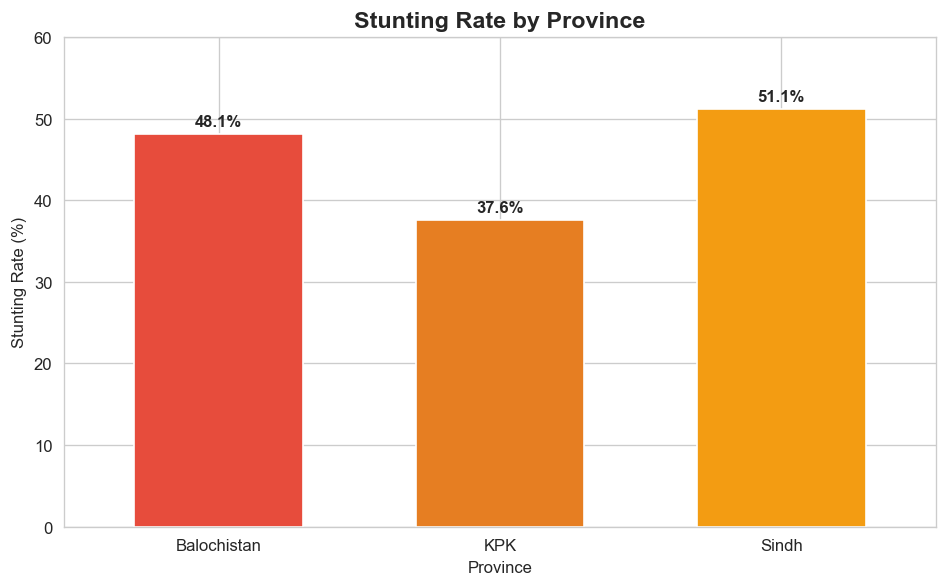

Plot 1 done!


In [5]:

# PLOT 1 — Stunting rate by Province

fig, ax = plt.subplots(figsize=(8, 5))
province_stunting = df.groupby('province_name')['stunted'].mean() * 100
colors = ['#e74c3c', '#e67e22', '#f39c12']
bars = province_stunting.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.6)
ax.set_title('Stunting Rate by Province', fontsize=14, fontweight='bold')
ax.set_xlabel('Province')
ax.set_ylabel('Stunting Rate (%)')
ax.set_ylim(0, 60)
for i, v in enumerate(province_stunting):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plot1_stunting_by_province.png")
plt.show()
print("Plot 1 done!")

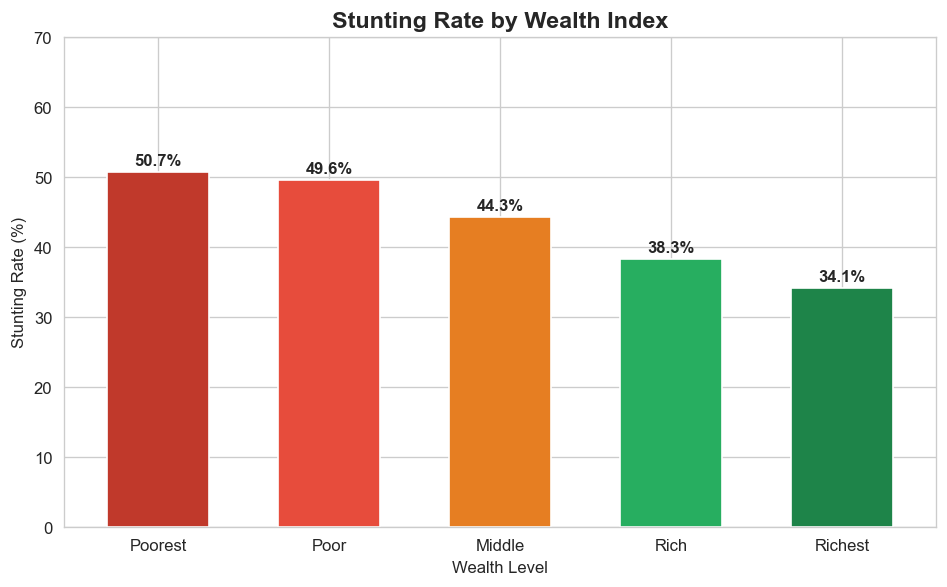

Plot 2 done!


In [6]:

# PLOT 2 — Stunting rate by Wealth Index

fig, ax = plt.subplots(figsize=(8, 5))
wealth_labels = {1: 'Poorest', 2: 'Poor', 3: 'Middle', 4: 'Rich', 5: 'Richest'}
df['wealth_label'] = df['wealth_index'].map(wealth_labels)
wealth_order = ['Poorest', 'Poor', 'Middle', 'Rich', 'Richest']
wealth_stunting = df.groupby('wealth_label')['stunted'].mean() * 100
wealth_stunting = wealth_stunting.reindex(wealth_order)
colors = ['#c0392b', '#e74c3c', '#e67e22', '#27ae60', '#1e8449']
wealth_stunting.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.6)
ax.set_title('Stunting Rate by Wealth Index', fontsize=14, fontweight='bold')
ax.set_xlabel('Wealth Level')
ax.set_ylabel('Stunting Rate (%)')
ax.set_ylim(0, 70)
for i, v in enumerate(wealth_stunting):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plot2_stunting_by_wealth.png")
plt.show()
print("Plot 2 done!")

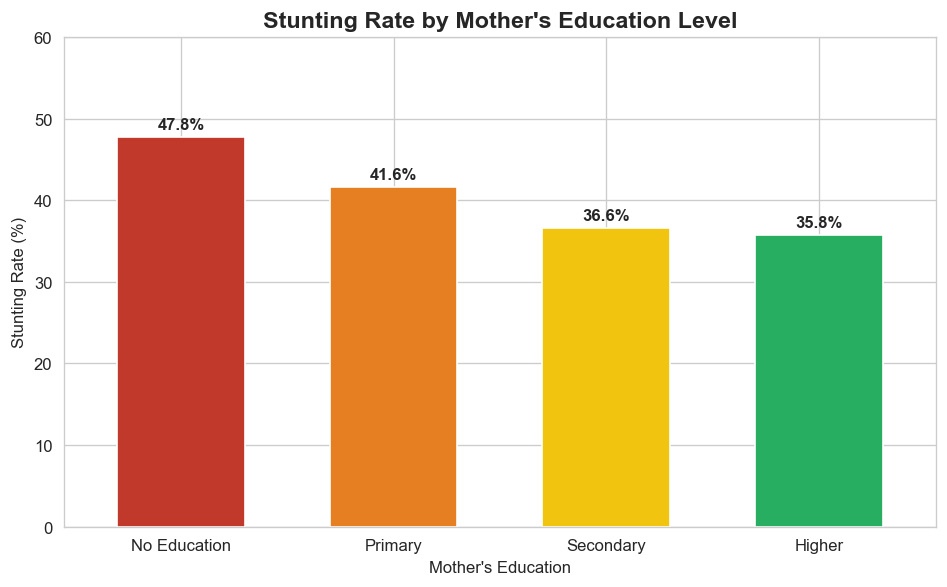

Plot 3 done!


In [7]:
# PLOT 3 — Stunting rate by Mother's Education
fig, ax = plt.subplots(figsize=(8, 5))
edu_labels = {0: 'No Education', 1: 'Primary', 2: 'Secondary', 3: 'Higher'}
df['edu_label'] = df['mother_education'].map(edu_labels)
edu_order = ['No Education', 'Primary', 'Secondary', 'Higher']
edu_stunting = df.groupby('edu_label')['stunted'].mean() * 100
edu_stunting = edu_stunting.reindex(edu_order)
colors = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60']
edu_stunting.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.6)
ax.set_title("Stunting Rate by Mother's Education Level", fontsize=14, fontweight='bold')
ax.set_xlabel("Mother's Education")
ax.set_ylabel('Stunting Rate (%)')
ax.set_ylim(0, 60)
for i, v in enumerate(edu_stunting):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plot3_stunting_by_education.png")
plt.show()
print("Plot 3 done!")

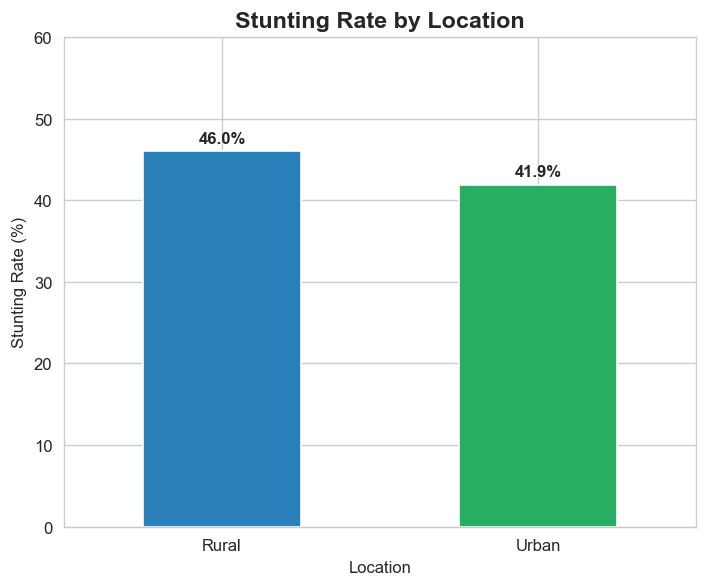

Plot 4 done!


In [8]:
# PLOT 4 — Stunting rate by Urban vs Rural
fig, ax = plt.subplots(figsize=(6, 5))
location_labels = {0: 'Urban', 1: 'Rural'}
df['location'] = df['urban_rural'].map(location_labels)
location_stunting = df.groupby('location')['stunted'].mean() * 100
colors = ['#2980b9', '#27ae60']
location_stunting.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.5)
ax.set_title('Stunting Rate by Location', fontsize=14, fontweight='bold')
ax.set_xlabel('Location')
ax.set_ylabel('Stunting Rate (%)')
ax.set_ylim(0, 60)
for i, v in enumerate(location_stunting):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plot4_stunting_by_location.png")
plt.show()
print("Plot 4 done!")

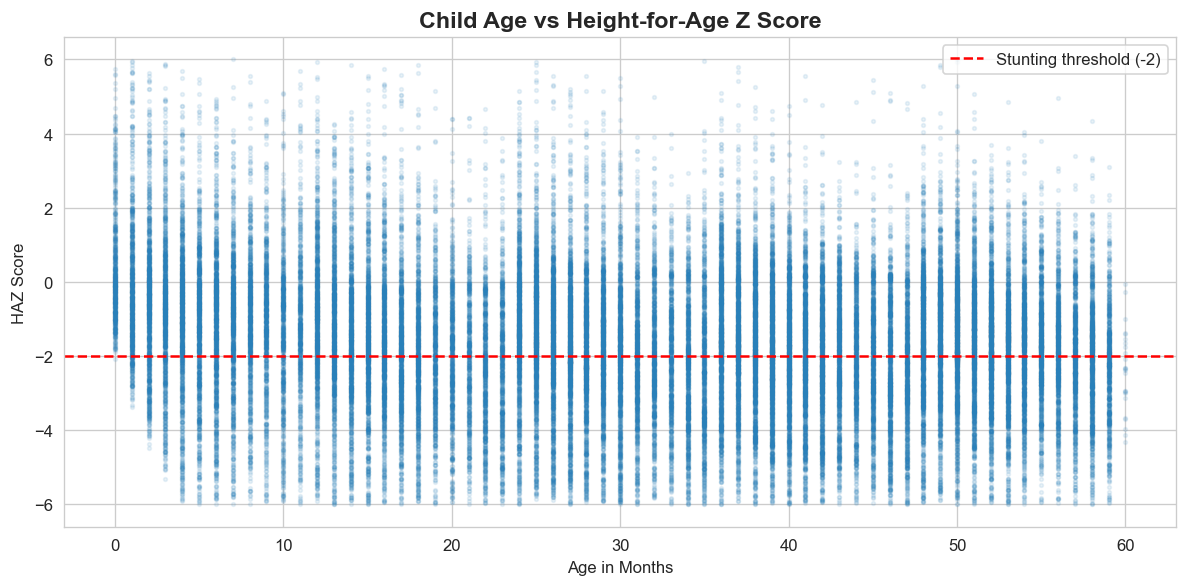

Plot 5 done!


In [9]:
# PLOT 5 — Age vs HAZ Score
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['child_age_months'], df['haz_score'],
           alpha=0.1, color='#2980b9', s=5)
ax.axhline(y=-2, color='red', linestyle='--', linewidth=1.5, label='Stunting threshold (-2)')
ax.set_title('Child Age vs Height-for-Age Z Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Age in Months')
ax.set_ylabel('HAZ Score')
ax.legend()
plt.tight_layout()
plt.savefig("plot5_age_vs_haz.png")
plt.show()
print("Plot 5 done!")

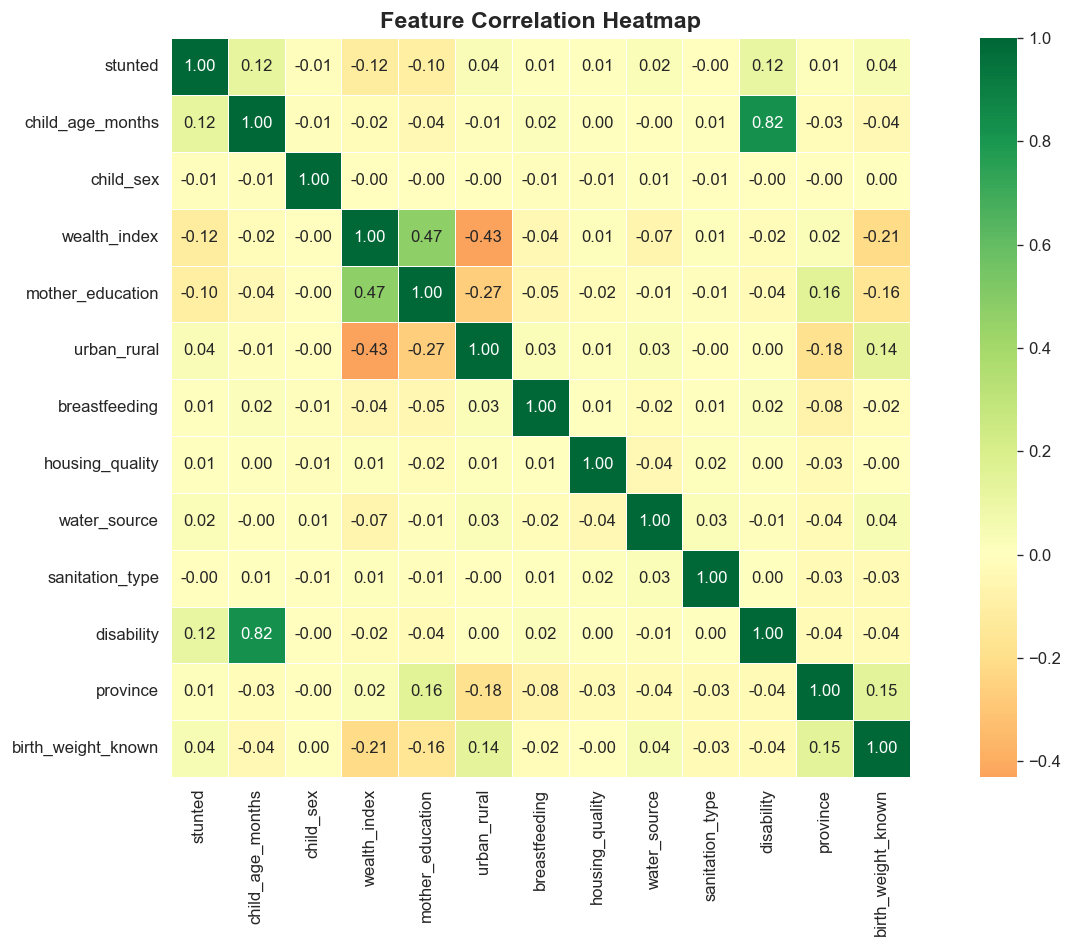

Plot 6 done!


In [10]:
# PLOT 6 — Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
cols_for_corr = ['stunted', 'child_age_months', 'child_sex', 'wealth_index',
                  'mother_education', 'urban_rural', 'breastfeeding',
                  'housing_quality', 'water_source', 'sanitation_type',
                  'disability', 'province', 'birth_weight_known']
corr = df[cols_for_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot6_correlation_heatmap.png")
plt.show()
print("Plot 6 done!")

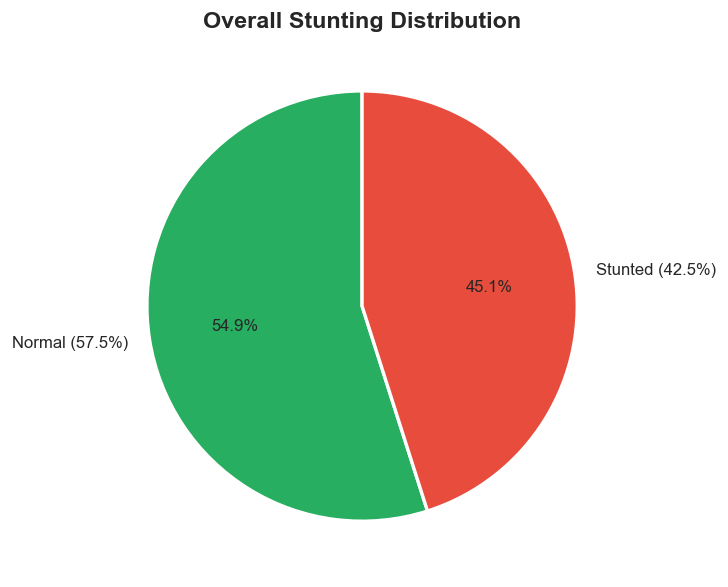

Plot 7 done!


In [11]:
#PLOT 7 — Overall Stunting Distribution

fig, ax = plt.subplots(figsize=(6, 5))
counts = df['stunted'].value_counts()
labels = ['Normal (57.5%)', 'Stunted (42.5%)']
colors = ['#27ae60', '#e74c3c']
ax.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Overall Stunting Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot7_stunting_distribution.png")
plt.show()
print("Plot 7 done!")

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix,
                              roc_auc_score, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# STEP 1 — Load & Prepare Data
df = pd.read_csv('../data/processed/final_dataset_clean.csv')

# Features and target
X = df.drop(columns=['stunted', 'underweight', 'wasted',
                       'haz_score', 'waz_score', 'whz_score',
                       'cluster_id', 'household_id'])
y = df['stunted']

print(f"Features: {X.columns.tolist()}")
print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

Features: ['child_age_months', 'child_sex', 'breastfeeding', 'mother_education', 'urban_rural', 'district', 'wealth_index', 'disability', 'province', 'birth_weight_known', 'housing_quality', 'water_source', 'sanitation_type', 'education_level', 'household_education']
X shape: (61050, 15)
y distribution:
stunted
0    33527
1    27523
Name: count, dtype: int64


In [4]:
# Drop string/label columns created during EDA
X = X.drop(columns=['province_name', 'wealth_label', 'edu_label', 'location'], errors='ignore')

print(f"Features: {X.columns.tolist()}")
print(f"X shape: {X.shape}")

# Redo train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]:,}")
print(f"Testing set: {X_test.shape[0]:,}")

Features: ['child_age_months', 'child_sex', 'breastfeeding', 'mother_education', 'urban_rural', 'district', 'wealth_index', 'disability', 'province', 'birth_weight_known', 'housing_quality', 'water_source', 'sanitation_type', 'education_level', 'household_education']
X shape: (61050, 15)
Training set: 48,840
Testing set: 12,210


In [5]:
# STEP 3 — Train All 3 Models

# Model 1 — Random Forest
print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
print("Random Forest done!")



Training Random Forest...
Random Forest done!


In [6]:
# Model 2 — Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]
print("Logistic Regression done!")

Training Logistic Regression...
Logistic Regression done!


In [7]:
# Model 3 — Decision Tree
print("Training Decision Tree...")
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]
print("Decision Tree done!")

Training Decision Tree...
Decision Tree done!


In [8]:
# STEP 4 — Evaluate All Models
def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred) * 100, 2),
        'F1 Score': round(f1_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred) * 100, 2),
        'Recall': round(recall_score(y_true, y_pred) * 100, 2),
        'ROC-AUC': round(roc_auc_score(y_true, y_prob) * 100, 2)
    }

results = pd.DataFrame([
    evaluate('Random Forest',     y_test, rf_pred, rf_prob),
    evaluate('Logistic Regression', y_test, lr_pred, lr_prob),
    evaluate('Decision Tree',     y_test, dt_pred, dt_prob),
])

print("\n=== MODEL COMPARISON ===")
print(results.to_string(index=False))


=== MODEL COMPARISON ===
              Model  Accuracy  F1 Score  Precision  Recall  ROC-AUC
      Random Forest     64.56     58.53      61.95   55.48    69.83
Logistic Regression     57.88     46.56      54.40   40.69    60.34
      Decision Tree     63.61     56.39      61.34   52.17    69.12


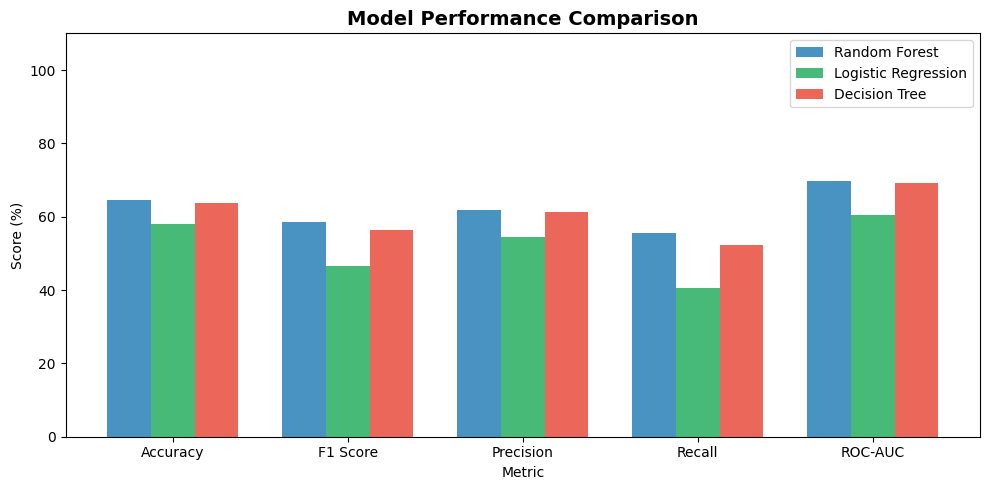

Model comparison plot done!


In [9]:
# STEP 5 — Plot Model Comparison

fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25
colors = ['#2980b9', '#27ae60', '#e74c3c']

for i, (_, row) in enumerate(results.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in metrics],
                  width, label=row['Model'], color=colors[i], alpha=0.85)

ax.set_xlabel('Metric')
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig("plot8_model_comparison.png")
plt.show()
print("Model comparison plot done!")

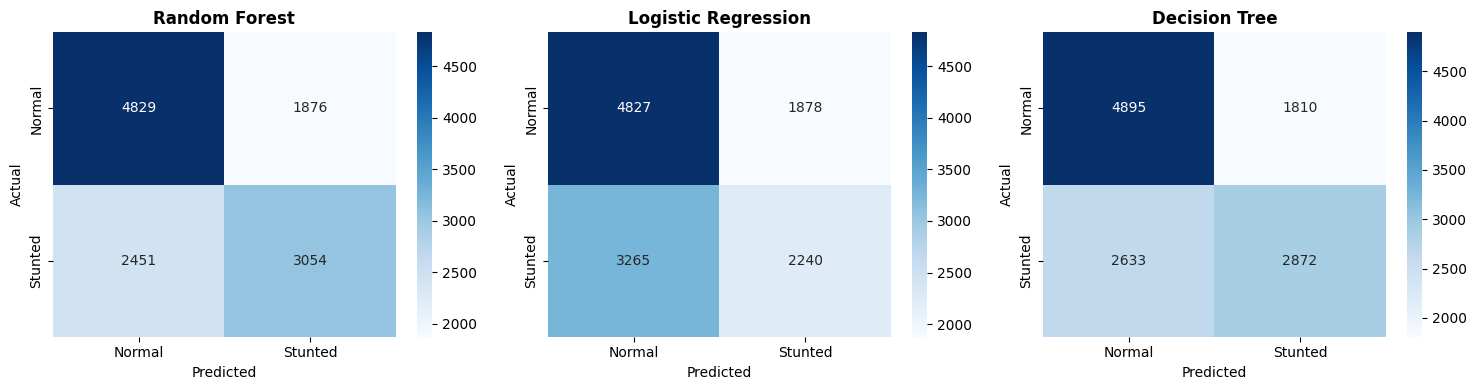

Confusion matrices done!


In [10]:
# STEP 6 — Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_info = [
    ('Random Forest', rf_pred),
    ('Logistic Regression', lr_pred),
    ('Decision Tree', dt_pred)
]
for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Stunted'],
                yticklabels=['Normal', 'Stunted'])
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig("plot9_confusion_matrices.png")
plt.show()
print("Confusion matrices done!")

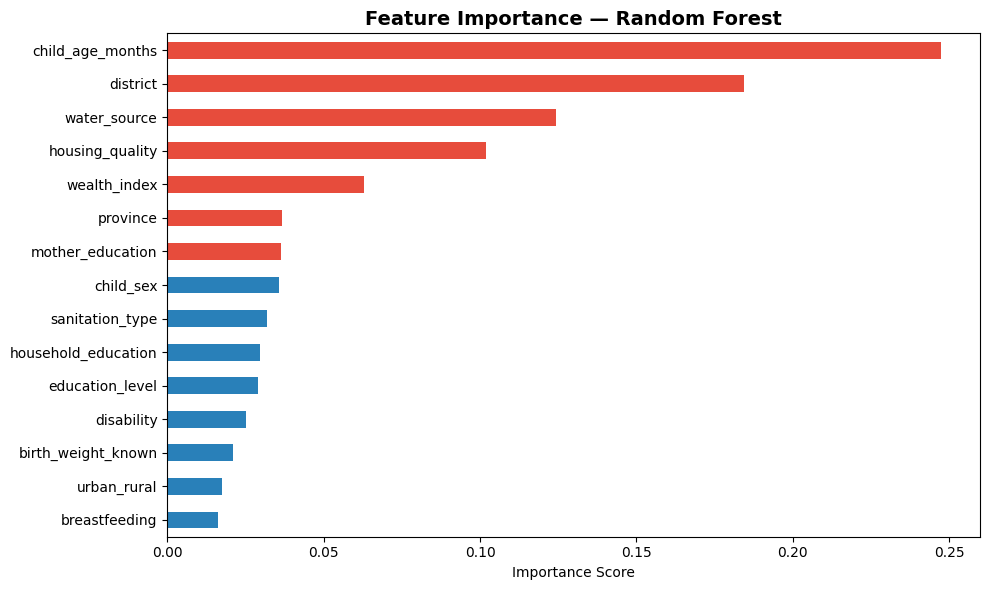

Feature importance plot done!


In [11]:
# STEP 7 — Feature Importance (Random Forest)
fig, ax = plt.subplots(figsize=(10, 6))
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)
colors = ['#e74c3c' if v > feat_imp.median() else '#2980b9' for v in feat_imp]
feat_imp.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig("plot10_feature_importance.png")
plt.show()
print("Feature importance plot done!")

In [12]:
# Improved Random Forest with better settings
rf_improved = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # handles class imbalance
    random_state=42,
    n_jobs=-1
)
rf_improved.fit(X_train, y_train)
rf_imp_pred = rf_improved.predict(X_test)
rf_imp_prob = rf_improved.predict_proba(X_test)[:, 1]

print("=== IMPROVED RANDOM FOREST ===")
print(f"Accuracy:  {accuracy_score(y_test, rf_imp_pred)*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, rf_imp_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, rf_imp_pred)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, rf_imp_pred)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_imp_prob)*100:.2f}%")

=== IMPROVED RANDOM FOREST ===
Accuracy:  66.43%
F1 Score:  64.13%
Precision: 61.87%
Recall:    66.56%
ROC-AUC:   72.17%


In [13]:
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ============================================
# Try XGBoost — usually best for tabular data
# ============================================
!pip install xgboost -q

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.2,  # handles class imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(f"Accuracy:  {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, xgb_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, xgb_pred)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, xgb_pred)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, xgb_prob)*100:.2f}%")


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
=== XGBoost ===
Accuracy:  66.86%
F1 Score:  64.82%
Precision: 62.16%
Recall:    67.72%
ROC-AUC:   73.22%


In [14]:
# ============================================
# Feature Engineering — create new features
# ============================================
df2 = pd.read_csv("final_dataset_clean.csv")

# Drop EDA label columns if they exist
df2 = df2.drop(columns=['province_name','wealth_label',
                          'edu_label','location'], errors='ignore')

# NEW FEATURE 1 — poverty + education combined risk score
df2['socio_risk'] = (5 - df2['wealth_index']) + (3 - df2['mother_education'])

# NEW FEATURE 2 — environment risk score
df2['env_risk'] = df2['water_source'] + df2['sanitation_type'] + df2['housing_quality']

# NEW FEATURE 3 — is child very young (under 24 months most vulnerable)
df2['early_age'] = (df2['child_age_months'] <= 24).astype(int)

# NEW FEATURE 4 — poorest AND rural (double disadvantage)
df2['poor_rural'] = ((df2['wealth_index'] <= 2) & (df2['urban_rural'] == 1)).astype(int)

# NEW FEATURE 5 — mother has no education AND poor
df2['unedu_poor'] = ((df2['mother_education'] == 0) & (df2['wealth_index'] <= 2)).astype(int)

# Prepare X and y
X2 = df2.drop(columns=['stunted', 'underweight', 'wasted',
                         'haz_score', 'waz_score', 'whz_score',
                         'cluster_id', 'household_id'])
y2 = df2['stunted']

print(f"Features now: {X2.shape[1]}")
print(f"New features added: socio_risk, env_risk, early_age, poor_rural, unedu_poor")

# Train test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

# Train XGBoost with new features
xgb2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.2,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb2.fit(X_train2, y_train2)
xgb2_pred = xgb2.predict(X_test2)
xgb2_prob = xgb2.predict_proba(X_test2)[:, 1]

print("\n=== XGBoost + Feature Engineering ===")
print(f"Accuracy:  {accuracy_score(y_test2, xgb2_pred)*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test2, xgb2_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test2, xgb2_pred)*100:.2f}%")
print(f"Recall:    {recall_score(y_test2, xgb2_pred)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test2, xgb2_prob)*100:.2f}%")

FileNotFoundError: [Errno 2] No such file or directory: 'final_dataset_clean.csv'

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

search = RandomizedSearchCV(
    xgb_base,
    param_grid,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best = search.best_estimator_
best_pred = best.predict(X_test)
best_prob = best.predict_proba(X_test)[:, 1]

print(f"Best params: {search.best_params_}")
print(f"\n=== TUNED XGBoost ===")
print(f"Accuracy:  {accuracy_score(y_test, best_pred)*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, best_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, best_pred)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, best_pred)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, best_prob)*100:.2f}%")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}

=== TUNED XGBoost ===
Accuracy:  67.36%
F1 Score:  62.36%
Precision: 64.95%
Recall:    59.96%
ROC-AUC:   73.67%


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier

# LightGBM — faster and often better than XGBoost
lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)
lgbm_prob = lgbm.predict_proba(X_test)[:, 1]

print("=== LightGBM ===")
print(f"Accuracy:  {accuracy_score(y_test, lgbm_pred)*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, lgbm_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, lgbm_pred)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, lgbm_pred)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, lgbm_prob)*100:.2f}%")

=== LightGBM ===
Accuracy:  67.12%
F1 Score:  65.25%
Precision: 62.32%
Recall:    68.47%
ROC-AUC:   73.58%
